In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
image_path = Path('.').parent / '/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025_edited/map.pgm'
output_path = Path('.').parent / '../output'  
output_path.mkdir(exist_ok=True)

print(f"Processing {image_path}...")


Processing /home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025_edited/map.pgm...


## Load the image

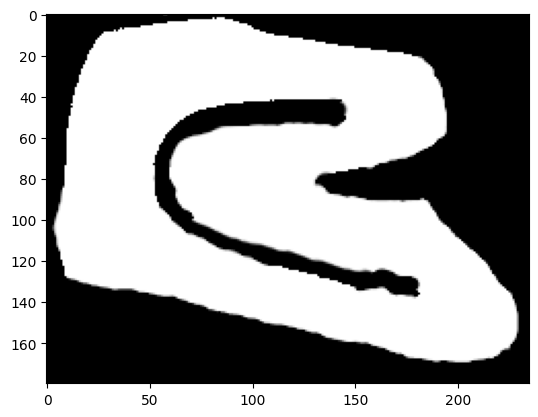

In [50]:
img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError(f"Could not load image from {image_path}")
plt.imshow(img, cmap='gray')

In [51]:
print(f"Loaded image with shape: {img.shape}")

# Threshold the image to create a binary image
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Invert if the track is white (assuming track is darker than background)
invert = False
if invert:
    binary = 255 - binary

Loaded image with shape: (180, 235)


In [52]:
# Find contours - for boundary extraction
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
len(contours)

2

In [53]:
# Find the largest contour on the track
largest_contour = max(contours, key=cv2.contourArea)
print("Largest contour has shape:", largest_contour.shape)

Largest contour has shape: (323, 1, 2)


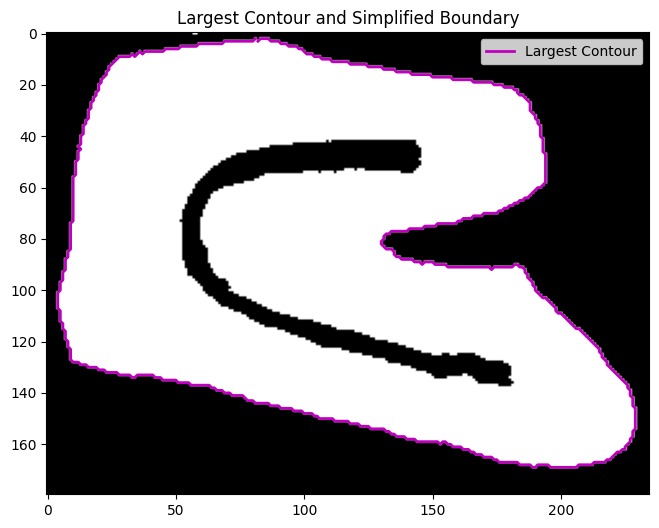

In [54]:
boundary_points = largest_contour

# Extract coordinates for plotting
largest_contour_coords =    [(point[0][0], point[0][1]) for point in largest_contour] # type: ignore
boundary_coords =           [(point[0][0], point[0][1]) for point in boundary_points] # type: ignore

# Plot immediately
plt.figure(figsize=(8, 6))
plt.imshow(binary, cmap='gray')  # Show the binary image as background
# Plot raw largest contour
largest_x = [p[0] for p in largest_contour_coords]
largest_y = [p[1] for p in largest_contour_coords]
plt.plot(largest_x, largest_y, 'm-', linewidth=2, label='Largest Contour')

plt.title('Largest Contour and Simplified Boundary')
plt.legend()
plt.show()


In [55]:

# Erode to create an artificial inner boundary
kernal_size = 2
kernel = np.ones((kernal_size, kernal_size), np.uint8)
iterations = 2
eroded = cv2.erode(binary, kernel, iterations=iterations)  # Adjust iterations as needed

# Extract all contours with hierarchy using RETR_CCOMP
contours, hierarchy = cv2.findContours(eroded, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

# Find the contour with the smallest area
inner_contour = None
if contours:
    inner_contour = min(contours, key=cv2.contourArea)
    # Optionally filter out tiny noise contours
    contour_noise = 2
    if cv2.contourArea(inner_contour) < contour_noise:  # Adjust threshold as needed
        print("Smallest contour too small, might be noise.")
        inner_contour = None


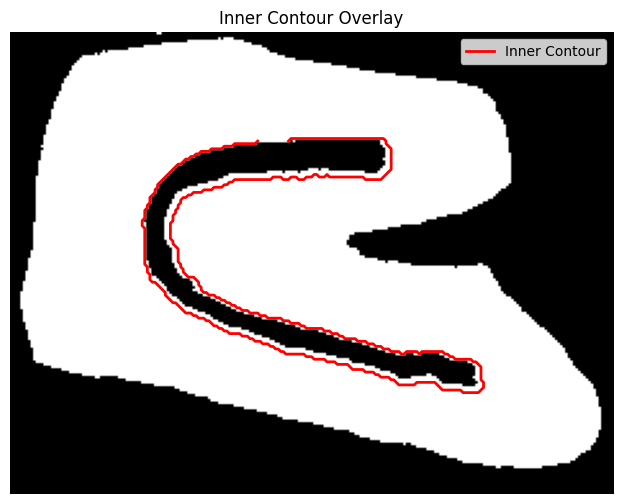

In [56]:
# --- Plot inner contour ---
if inner_contour is not None:
    # Reshape into (N,2) and split x/y
    pts = inner_contour.reshape(-1, 2)
    xs, ys = pts[:,0], pts[:,1]

    plt.figure(figsize=(8,6))
    plt.imshow(binary, cmap='gray')       # or plt.imshow(img, cmap='gray')
    plt.plot(xs, ys, 'r-', linewidth=2, label='Inner Contour')
    plt.legend()
    plt.title("Inner Contour Overlay")
    plt.axis('off')  # optional
    plt.show()
else:
    print("No valid inner contour to plot.")

In [57]:
inner_contour  = inner_contour.reshape(-1, 2)  # type: ignore
inner_contour_coords = inner_contour
inner_contour_coords.shape

(232, 2)

In [58]:
import numpy as np
import cv2

midpoints = []

# Convert contours to NumPy arrays
inner_array = np.array(inner_contour_coords)
outer_array = np.array(largest_contour_coords)

def does_line_cross_contour(p1, p2, contour):
    """
    Check if the line segment (p1 -> p2) intersects the given contour.
    """
    for i in range(len(contour)):
        q1 = contour[i]
        q2 = contour[(i + 1) % len(contour)]  # Wrap around
        if cv2.clipLine((q1[0], q1[1], q2[0], q2[1]), p1, p2):
            return True  # Line crosses the contour
    return False

for inner_point in inner_contour_coords:
    # Compute distances
    distances = np.linalg.norm(outer_array - np.array(inner_point), axis=1)

    # Sort indices by distance
    sorted_indices = np.argsort(distances)

    # Find the closest valid outer point (not crossing the track)
    for closest_index in sorted_indices:
        outer_point = largest_contour_coords[closest_index]
        
        # Check if the midpoint crosses the inner contour (i.e., the "wall")
        if not does_line_cross_contour(inner_point, outer_point, inner_array):
            # Compute midpoint
            midpoint_x = (inner_point[0] + outer_point[0]) / 2
            midpoint_y = (inner_point[1] + outer_point[1]) / 2
            midpoint = (midpoint_x, midpoint_y)

            midpoints.append(midpoint)
            print(f"Midpoint between {inner_point} and {outer_point} is {midpoint}")
            break  # Found a valid point, move to the next inner point


In [59]:
# Skeletonize to get centerline
# Distance transform + adaptive thresholding
dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)

# Normalize for visualization
dist_norm = cv2.normalize(dist_transform, None, 0, 1.0, cv2.NORM_MINMAX) # type: ignore

# Improve skeleton by using an adaptive threshold based on max distance
max_dist = np.max(dist_transform[binary > 0])  # Max distance within track
factor = 0.5 ## Factor
thresh_value = max_dist * factor  # Threshold at half the max distance (adjustable)
_, skeleton = cv2.threshold(dist_transform, thresh_value, 255, cv2.THRESH_BINARY) # type: ignore
skeleton = skeleton.astype(np.uint8)

# Optional: Thin the skeleton with a single erosion step to refine it
kernel = np.ones((3, 3), np.uint8)
skeleton = cv2.erode(skeleton, kernel, iterations=1)

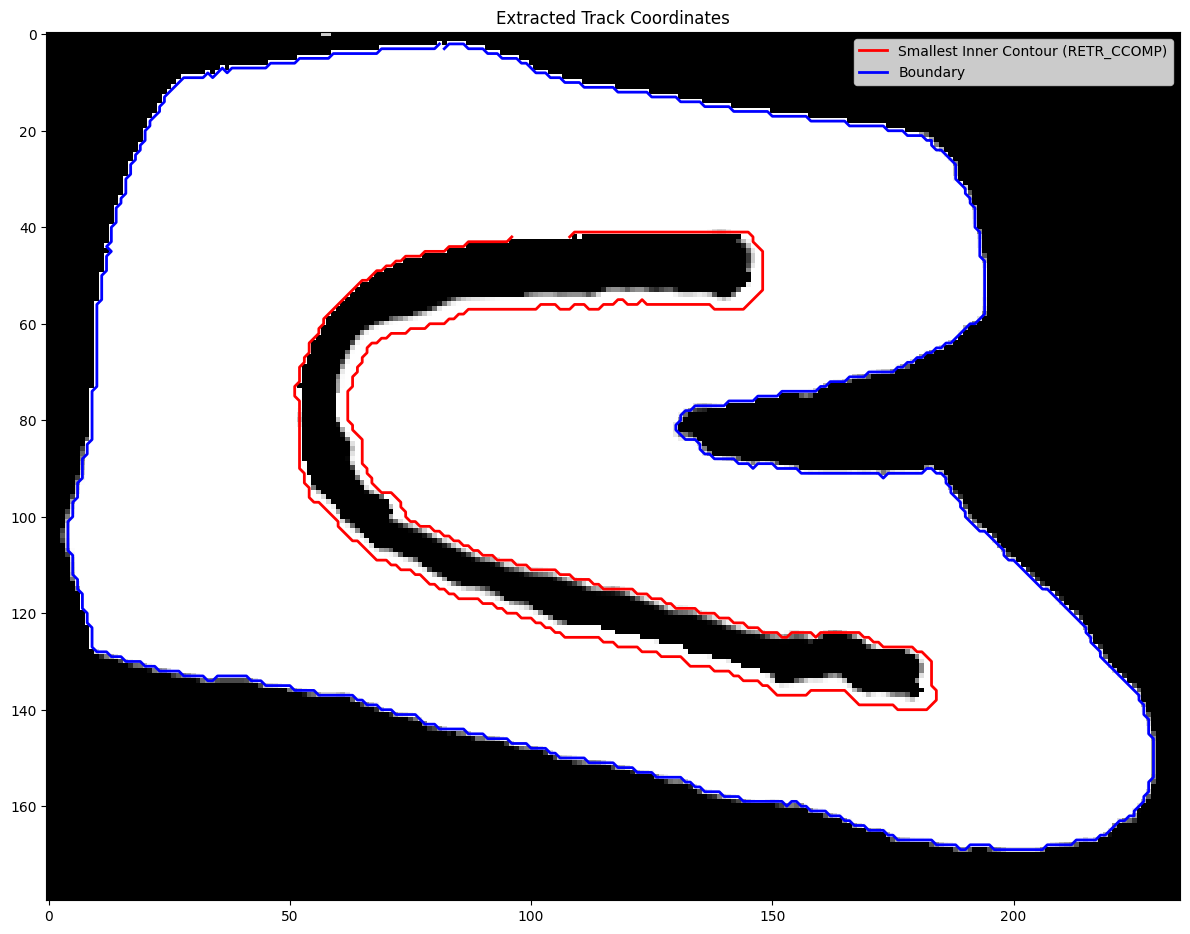

<Figure size 640x480 with 0 Axes>

In [13]:
# Visualize results

plt.figure(figsize=(12, 10))

# Result with coordinates
plt.imshow(img, cmap='gray')

boundary_x = [p[0] for p in boundary_coords]
boundary_y = [p[1] for p in boundary_coords]

# if inner_contour_coords:
inner_x = [p[0] for p in inner_contour_coords]
inner_y = [p[1] for p in inner_contour_coords]
plt.plot(inner_x, inner_y, 'r-', linewidth=2, label='Smallest Inner Contour (RETR_CCOMP)')

plt.plot(boundary_x, boundary_y, 'b-', linewidth=2, label='Boundary')
plt.title('Extracted Track Coordinates')
plt.legend()

plt.tight_layout()
plt.show()
if output_path:
    plt.savefig(output_path / 'track_with_coords.png')

## Adjust the Threshold Dynamically
Instead of a fixed max_dist * 0.5, try a lower or adaptive threshold to include more of the central region:


Using OpenCV thinning.


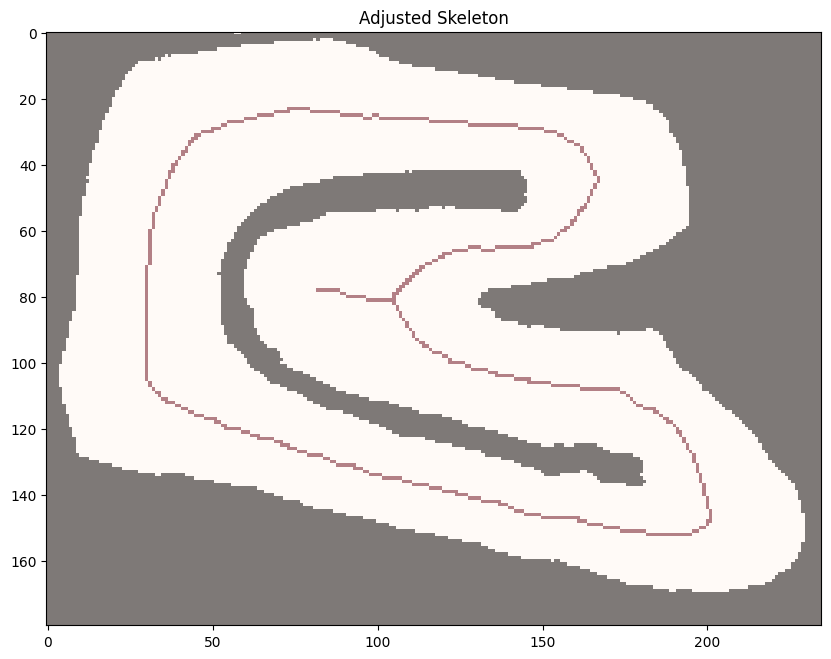

Skeleton pixels: 624


In [60]:
dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
max_dist = np.max(dist_transform[binary > 0])
thresh_value = max_dist * 0.3  # Try 0.3 or 0.2 to widen the skeleton initially
_, skeleton = cv2.threshold(dist_transform, thresh_value, 255, cv2.THRESH_BINARY)
skeleton = skeleton.astype(np.uint8)

# Optional: Thin it
try:
    import cv2
    skeleton = cv2.ximgproc.thinning(skeleton)  # Preferred if available
    print("Using OpenCV thinning.")
except ImportError:
    kernel = np.ones((3, 3), np.uint8)
    skeleton = cv2.erode(skeleton, kernel, iterations=1)

# Check result
plt.figure(figsize=(10, 8))
plt.imshow(binary, cmap='gray')
plt.imshow(skeleton, cmap='Reds', alpha=0.5)
plt.title('Adjusted Skeleton')
plt.show()
print(f"Skeleton pixels: {cv2.countNonZero(skeleton)}")

## Smooth the Binary Image First

If the track’s boundaries are jagged or uneven, smooth them before the distance transform:


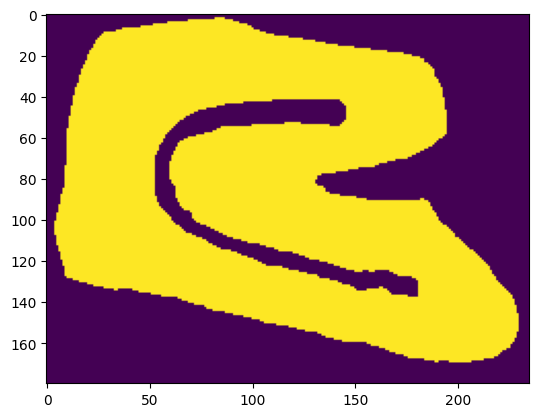

In [15]:
# Smooth binary to even out boundaries
binary_smoothed = cv2.GaussianBlur(binary, (5, 5), 0)
_, binary_smoothed = cv2.threshold(binary_smoothed, 127, 255, cv2.THRESH_BINARY)

plt.imshow(binary_smoothed)

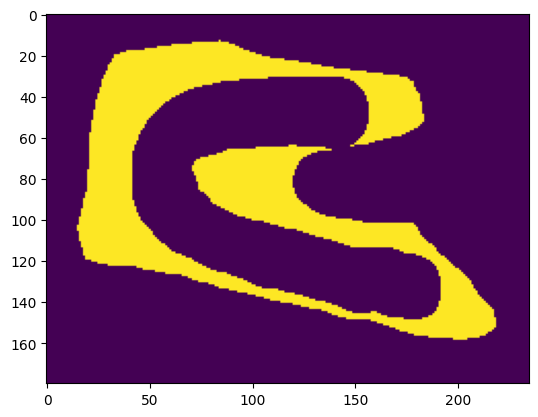

In [16]:
dist_transform = cv2.distanceTransform(binary_smoothed, cv2.DIST_L2, 5)
max_dist = np.max(dist_transform[binary_smoothed > 0])
thresh_value = max_dist * 0.4  # Middle ground
_, skeleton = cv2.threshold(dist_transform, thresh_value, 255, cv2.THRESH_BINARY) # type: ignore
skeleton = skeleton.astype(np.uint8)
plt.imshow(skeleton)

Used ximgproc OpenCV thinning.


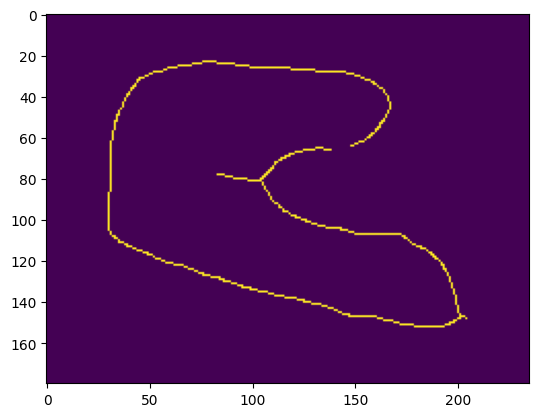

In [17]:
# Thin it
try:
    skeleton = cv2.ximgproc.thinning(skeleton)
    print("Used ximgproc OpenCV thinning.")
except ImportError:
    print("Using basic thinning.")
    kernel = np.ones((3, 3), np.uint8)
    skeleton = cv2.erode(skeleton, kernel, iterations=1)
plt.imshow(skeleton)

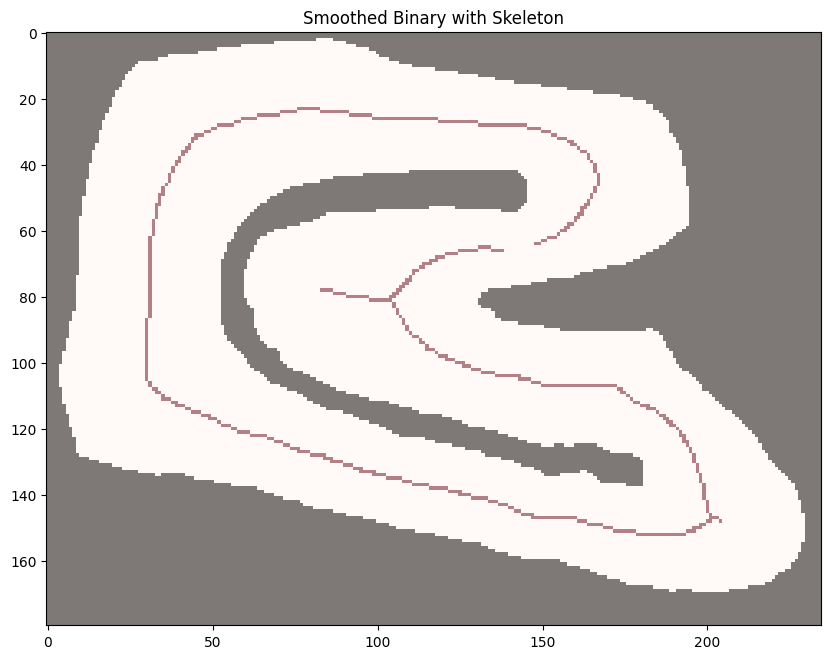

In [18]:
y_coords, x_coords = np.where(skeleton > 0)  # Get row (y) and column (x) indices
skeleton_points = np.array(list(zip(x_coords, y_coords)))  # Combine into (x, y) pairs

# Save if needed
if output_path:
    cv2.imwrite(str(output_path / 'smoothed_binary_skeleton.png'), skeleton)

# Visualize
plt.figure(figsize=(10, 8))
plt.imshow(binary_smoothed, cmap='gray')
plt.imshow(skeleton, cmap='Reds', alpha=0.5)
plt.title('Smoothed Binary with Skeleton')
plt.show()

## Use a completely different approach with a Medial Axis Transform

The Medial Axis Transform (MAT) is a skeletonization algorithm that is based on the distance transform. The MAT is a thinning algorithm that reduces the binary image to its skeleton. The skeleton is a set of lines that are equidistant to the edges of the binary image. The MAT is a powerful tool for shape analysis and pattern recognition.

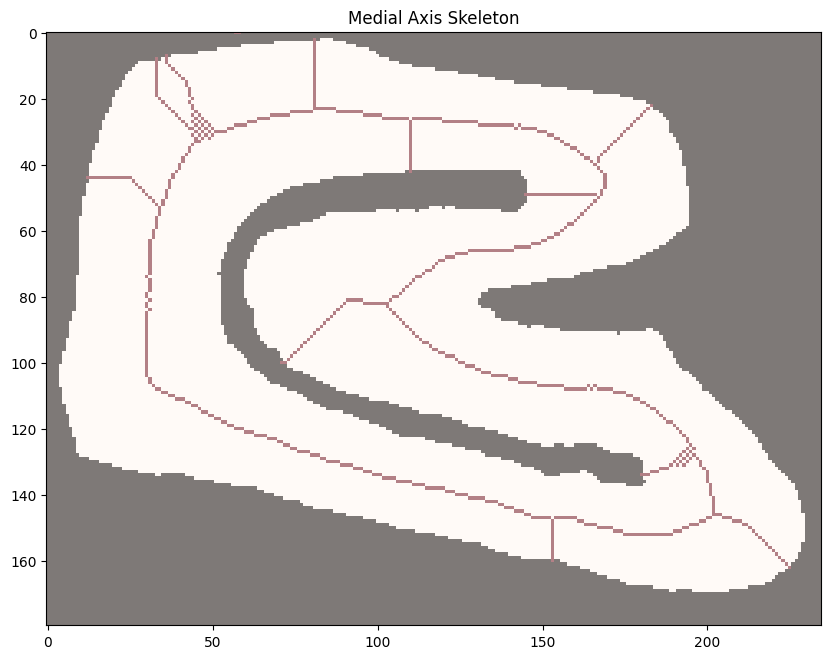

Skeleton pixels: 803


In [19]:
from skimage.morphology import  medial_axis
import numpy as np

# Convert binary to boolean (True for 255, False for 0)
binary_bool = binary > 0

# Medial axis transform (returns skeleton and distance)
skeleton, distance = medial_axis(binary_bool, return_distance=True)

# Convert back to uint8
skeleton = (skeleton * 255).astype(np.uint8)

# Visualize
plt.figure(figsize=(10, 8))
plt.imshow(binary, cmap='gray')
plt.imshow(skeleton, cmap='Reds', alpha=0.5)
plt.title('Medial Axis Skeleton')
plt.show()
print(f"Skeleton pixels: {cv2.countNonZero(skeleton)}")

y_coords, x_coords = np.where(skeleton > 0)  # Get row (y) and column (x) indices
skeleton_points = np.array(list(zip(x_coords, y_coords)))  # Combine into (x, y) pairs

# Save if needed
if output_path:
    cv2.imwrite(str(output_path / 'medial_axis_smoothed_skeleton.png'), skeleton)

# Start to make structured functions

In [20]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

In [21]:
image_path = Path('.').parent / '/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025_edited/map.pgm'
image_dir = image_path.parent
start_line_path = image_dir / 'map_start_line.png'
start_line_color = (0, 0, 255)  # Green color for the start line
output_path = Path('.').parent / '../output'  
output_path.mkdir(exist_ok=True)

print(f"Processing {image_path}...")

Processing /home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025_edited/map.pgm...


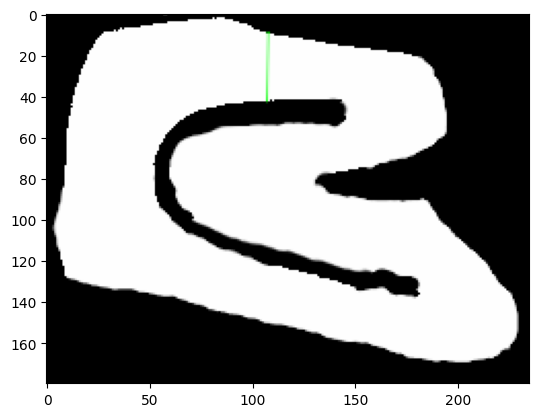

In [22]:
# Load the start line image
start_line_img = cv2.imread(str(start_line_path))
# Show the start line image
plt.imshow(start_line_img)

In [23]:
from typing import List, Tuple
from numpy.typing import NDArray

def extract_green_line_coordinates(img) -> List[np.int_]:
    """
    Loads an image, identifies green pixels based on a defined HSV range,
    and returns their (x, y) coordinates. The selection is inherently binary
    based on the range.

    Args:
        image_path: The path to the image file.

    Returns:
        A numpy array of shape (N, 2) containing the (x, y) coordinates
        of the green pixels, or an empty array if no green pixels are found
        or the image fails to load. Coordinates are integers.
    """
    # Check if image loading was successful
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return np.empty((0, 2), dtype=np.int_)

    # Convert the image from BGR to HSV
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Define the lower and upper bounds for green color in HSV
    # Adjust these values based on your specific image's green color and lighting.
    # A reasonable range:
    lower_green = np.array([30, 50, 50])
    upper_green = np.array([90, 255, 255])


    # Create a binary mask: pixels within the green range are 255, others are 0
    green_mask = cv2.inRange(hsv_img, lower_green, upper_green)

    # --- COORDINATE EXTRACTION ---
    # Find the indices of pixels where the mask is > 0 (i.e., green)
    # np.where returns (row_indices, col_indices)
    y_coords_rows, x_coords_cols = np.where(green_mask > 0)

    # Combine the column indices (x) and row indices (y) into an Nx2 array
    # The standard (x, y) format has x as the first element, y as the second.
    coordinates: NDArray[np.int_] = np.column_stack((x_coords_cols, y_coords_rows))
    # --- END OF COORDINATE EXTRACTION ---


    return coordinates
# Extract coordinates


In [24]:
start_line_coords = extract_green_line_coordinates(start_line_img)
start_line_coords

array([[107,   9],
       [108,   9],
       [108,  10],
       [108,  11],
       [108,  12],
       [108,  13],
       [107,  14],
       [108,  14],
       [107,  15],
       [108,  15],
       [107,  16],
       [108,  16],
       [107,  17],
       [108,  17],
       [107,  18],
       [108,  18],
       [107,  19],
       [108,  19],
       [107,  20],
       [108,  20],
       [107,  21],
       [108,  21],
       [107,  22],
       [108,  22],
       [107,  23],
       [108,  23],
       [107,  24],
       [108,  24],
       [107,  25],
       [107,  26],
       [107,  27],
       [107,  28],
       [107,  29],
       [107,  30],
       [107,  31],
       [107,  32],
       [107,  33],
       [107,  34],
       [107,  35],
       [107,  36],
       [107,  37],
       [107,  38],
       [107,  39],
       [107,  40],
       [107,  41],
       [107,  42],
       [107,  43]])

Text(0.5, 1.0, 'Start Line Coordinates')

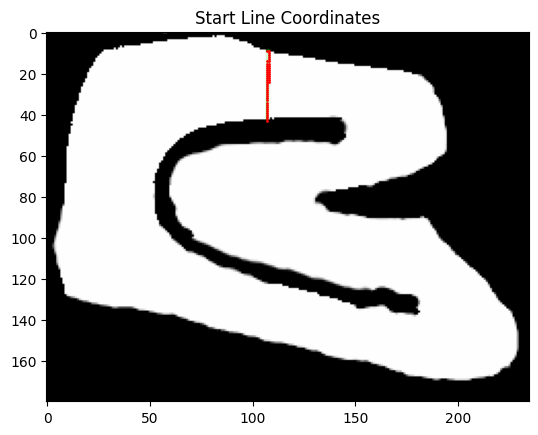

In [25]:

# Show the start line coordinates
plt.imshow(start_line_img)
plt.scatter(start_line_coords[:, 0], start_line_coords[:, 1], c='red', s=1)  # Red dots for start line
plt.title('Start Line Coordinates')

In [26]:
def load_binary_image(image_path: str, invert: bool) -> np.ndarray:
    """
    Load a binary image from the specified path.
    """
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not load image from {image_path}")
    print(f"Loaded image with shape: {img.shape}")

    # Threshold the image to create a binary image
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Invert if the track is white (assuming track is darker than background)
    invert = False
    if invert:
        binary = 255 - binary
    return binary

Loaded image with shape: (180, 235)


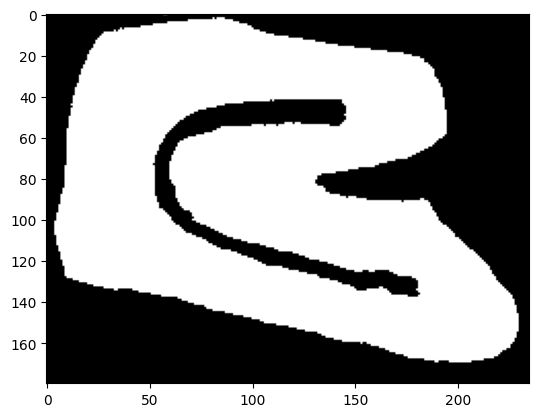

In [27]:
img = load_binary_image(image_path, invert=False)
plt.imshow(img, cmap='gray')

In [28]:
def find_outer_border(binary_image: cv2.typing.MatLike) -> cv2.typing.MatLike:
   contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

   # Find the largest contour on the track
   boundary_points = max(contours, key=cv2.contourArea)
   print("Largest contour has shape:", boundary_points.shape)

   # Extract coordinates for plotting
   boundary_coords =  [(point[0][0], point[0][1]) for point in boundary_points] # type: ignore
   return boundary_coords
    

Largest contour has shape: (323, 1, 2)


Text(0.5, 1.0, 'Outer Border')

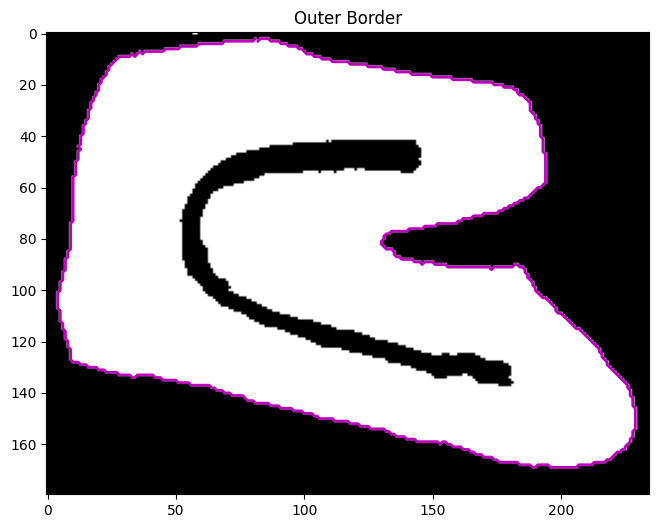

In [29]:
outer_border = find_outer_border(img)

# Plot immediately
plt.figure(figsize=(8, 6))
plt.imshow(img, cmap='gray')  # Show the binary image as background
# Plot raw largest contour
outer_x = [p[0] for p in outer_border]
outer_y = [p[1] for p in outer_border]
plt.plot(outer_x, outer_y, 'm-', linewidth=2, label='Outer Border')
plt.title('Outer Border')

In [30]:
def sample_waypoints(points: np.ndarray, num_points: int) -> np.ndarray:
    """
    Sample a specified number of waypoints evenly along a polyline defined by points.

    Args:
        points: An (N,2) array of (x,y) coordinates defining the path.
        num_points: Number of waypoints to sample.

    Returns:
        An (num_points,2) array of sampled (x,y) coordinates.
    """
    # Compute segment lengths
    diffs = np.diff(points, axis=0)
    seg_lengths = np.hypot(diffs[:,0], diffs[:,1])
    cumulative = np.concatenate(([0], np.cumsum(seg_lengths)))
    total_length = cumulative[-1]

    # Desired distances along the path
    distances = np.linspace(0, total_length, num_points)

    # Allocate output
    waypoints = np.zeros((num_points, 2), dtype=float)

    # Walk through segments to interpolate
    idx = 0
    for i, d in enumerate(distances):
        # Move idx to segment containing this distance
        while idx < len(cumulative)-2 and d > cumulative[idx+1]:
            idx += 1
        # Interpolate between points[idx] and points[idx+1]
        t = (d - cumulative[idx]) / (cumulative[idx+1] - cumulative[idx]) if cumulative[idx+1] > cumulative[idx] else 0
        waypoints[i] = (1 - t) * points[idx] + t * points[idx+1]
    return waypoints

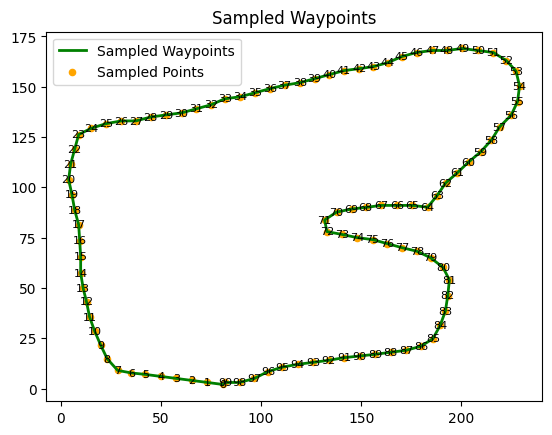

In [31]:
outer_waypoints = sample_waypoints(np.array(outer_border), 100)
# Plot sampled waypoints
plt.plot(outer_waypoints[:,0], outer_waypoints[:,1], 'g-', linewidth=2, label='Sampled Waypoints')
# Put actual scatter points to see them
plt.scatter(outer_waypoints[:,0], outer_waypoints[:,1], c='orange', s=20, label='Sampled Points')
# Add a text label to each waypoint
for i, (x, y) in enumerate(outer_waypoints):
    plt.text(x, y, str(i), fontsize=8, color='black', ha='center', va='center')
plt.title('Sampled Waypoints')
plt.legend()
plt.show()

In [32]:
import numpy as np
from typing import List, Tuple, Union
from numpy.typing import NDArray

Point = Union[Tuple[float, float], List[float], NDArray[np.floating]]

def generate_evenly_spaced_points(
    waypoints: Union[List[Point], NDArray[np.floating]],
    spacing: float
) -> NDArray[np.floating]:
    """
    Generates new waypoints with approximately even spacing along the route
    defined by the original waypoints.

    Args:
        waypoints: A list of points (each a tuple or list of two floats) or
                   a numpy array of shape (N, 2) containing float coordinates.
        spacing: The desired approximate distance between consecutive generated points.

    Returns:
        A numpy array of generated (x, y) waypoints with a float dtype.
        The shape will be (M, 2), where M depends on the total length and spacing.
    """
    # Type validation and conversion to numpy array
    if not isinstance(spacing, (int, float)) or spacing <= 0:
         raise ValueError("spacing must be a positive number.")

    # --- CORRECTED CHECK FOR EMPTY ARRAY ---
    if isinstance(waypoints, np.ndarray):
        # Check if the numpy array is empty
        if waypoints.shape[0] == 0:
            return np.empty((0, 2), dtype=np.float64)
        waypoints_np = waypoints.astype(np.float64) # Ensure float dtype
        if waypoints_np.ndim != 2 or waypoints_np.shape[1] != 2:
             raise ValueError("Waypoints numpy array must be of shape (N, 2).")
    elif isinstance(waypoints, list):
        # Check if the list is empty
        if not waypoints:
             return np.empty((0, 2), dtype=np.float64)
         # Ensure elements are convertible to float and have 2 dimensions
        waypoints_np = np.array(waypoints, dtype=np.float64)
        if waypoints_np.ndim != 2 or waypoints_np.shape[1] != 2:
             raise ValueError("Waypoints list must contain 2D points.")
    else:
        raise TypeError("Waypoints must be a list or a numpy array.")
    # --- END OF CORRECTED CHECK ---


    if len(waypoints_np) < 2:
        # Cannot form segments with less than 2 points
        # If there's 0 or 1 point, return it/them as a numpy array
        return waypoints_np


    # 1. Calculate segment lengths
    # Differences between consecutive points
    diffs: NDArray[np.floating] = np.diff(waypoints_np, axis=0)
    # Euclidean distance for each segment
    segment_lengths: NDArray[np.floating] = np.sqrt(np.sum(diffs**2, axis=1))

    # 2. Calculate cumulative lengths
    # Add 0 as the starting cumulative length
    cumulative_lengths: NDArray[np.floating] = np.insert(np.cumsum(segment_lengths), 0, 0.0)

    # 3. Determine the total length
    total_length: float = cumulative_lengths[-1]

    # If the total length is zero (all points are the same), return just one point
    if total_length < 1e-9: # Use a small tolerance for floating point comparison
        return waypoints_np[:1] # Return the first point as a (1, 2) array


    # 4. Generate target distances along the route
    # Create points at multiples of the desired spacing, up to the total length
    target_distances: NDArray[np.floating] = np.arange(0.0, total_length + spacing, spacing)

    # Ensure the very last point is included even if total_length isn't a perfect multiple of spacing
    # Remove targets beyond total length and add the exact total length if it's not already there
    target_distances = target_distances[target_distances <= total_length]
    if target_distances[-1] < total_length:
         target_distances = np.append(target_distances, total_length)


    # 5. Find the segment for each target distance and interpolate
    generated_waypoints_list: List[NDArray[np.floating]] = []

    # Use searchsorted to find which segment interval each target distance falls into
    # searchsorted finds the index where the element would be inserted to maintain order.
    # For a distance d, searchsorted(cumulative_lengths, d) will give the index i
    # such that cumulative_lengths[i-1] <= d < cumulative_lengths[i].
    # This means the distance d falls within the segment connecting waypoint i-1 and waypoint i.
    # Using side='right' is important to correctly handle target distances that are exactly
    # equal to a cumulative length (i.e., fall exactly on an original waypoint).
    segment_indices: NDArray[np.int_] = np.searchsorted(cumulative_lengths, target_distances, side='right') - 1

    # Handle the edge case for the very last point which might result in segment_idx = len(waypoints_np) - 1
    # if target_distances[-1] == total_length. The segment index should be len(waypoints_np) - 2
    # to reference the segment *ending* at the last point.
    segment_indices[segment_indices == len(waypoints_np) - 1] = len(waypoints_np) - 2


    for i, target_dist in enumerate(target_distances):
        segment_idx: int = segment_indices[i]

        # Get the points defining the segment
        p1: NDArray[np.floating] = waypoints_np[segment_idx]
        p2: NDArray[np.floating] = waypoints_np[segment_idx + 1]

        # Get the cumulative lengths at the start and end of the segment
        start_cumulative_length: float = cumulative_lengths[segment_idx]
        # The length of the current segment
        segment_len: float = segment_lengths[segment_idx] # Use pre-calculated segment length


        # Calculate the parameter 't' for linear interpolation within this segment
        # t represents the position of the target distance along the current segment,
        # normalized between 0 and 1.
        if segment_len > 1e-9: # Avoid division by zero for very short segments
            t: float = (target_dist - start_cumulative_length) / segment_len
            # Clamp t to be between 0 and 1 due to potential floating point inaccuracies
            t = max(0.0, min(1.0, t))
        else:
             # If segment is zero length, the point is the start point of the segment
             t: float = 0.0

        # Linearly interpolate to find the point coordinates
        # P(t) = (1-t)*P1 + t*P2
        interp_point: NDArray[np.floating] = (1.0 - t) * p1 + t * p2

        generated_waypoints_list.append(interp_point)

    # Stack the list of points into a numpy array
    if not generated_waypoints_list:
         return np.empty((0, 2), dtype=np.float64)

    return np.vstack(generated_waypoints_list)

In [33]:
import numpy as np
import cv2

def find_inner_border(binary_image: cv2.typing.MatLike) -> cv2.typing.MatLike:
    """
    Find the inner border of a binary image.
    
    Args:
        binary_image: Binary image
        
    Returns:
        Inner border contour as array of points
    """
    # Erode to create an artificial inner boundary
    kernal_size = 2
    kernel = np.ones((kernal_size, kernal_size), np.uint8)
    iterations = 2
    eroded = cv2.erode(binary_image, kernel, iterations=iterations)
    
    # Extract all contours with hierarchy using RETR_CCOMP
    contours, _ = cv2.findContours(eroded, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    
    # Find the contour with the smallest area
    inner_contour = None
    if contours:
        inner_contour = min(contours, key=cv2.contourArea)
        
        # Optionally filter out tiny noise contours
        contour_noise = 2
        if cv2.contourArea(inner_contour) < contour_noise:
            print("Smallest contour too small, might be noise.")
            inner_contour = None
    
    if inner_contour is not None:
        # Convert from nested structure to a simple array of points
        inner_contour = inner_contour.reshape(-1, 2)
        
        # Make sure the contour is closed by adding the first point at the end
        if not np.array_equal(inner_contour[0], inner_contour[-1]):
            inner_contour = np.append(inner_contour, [inner_contour[0]], axis=0)
        
        
        return generate_evenly_spaced_points(inner_contour, 1)
    return np.array([])

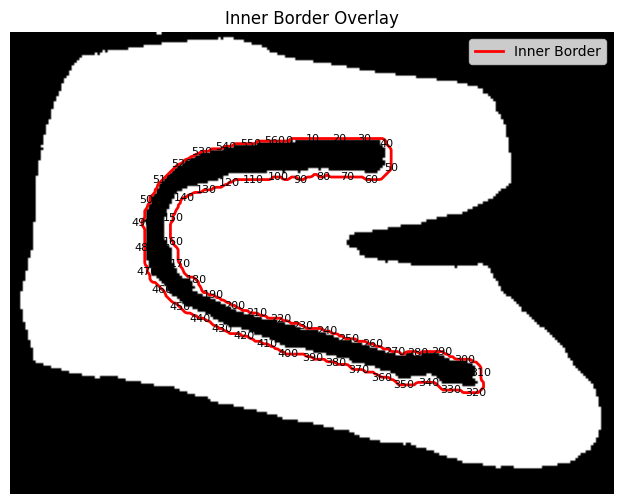

In [34]:
inner_border = find_inner_border(img)
# Plot inner contour
if inner_border is not None:
    # Reshape into (N,2) and split x/y
    pts = inner_border.reshape(-1, 2)
    xs, ys = pts[:,0], pts[:,1]

    plt.figure(figsize=(8,6))
    plt.imshow(img, cmap='gray')       # or plt.imshow(img, cmap='gray')
    plt.plot(xs, ys, 'r-', linewidth=2, label='Inner Border')
    # Add a text label to each waypoint
    for i, (x, y) in enumerate(inner_border):
        if i % 10 == 0:
            plt.text(x, y, str(i), fontsize=8, color='black', ha='center', va='center')
    plt.legend()
    plt.title("Inner Border Overlay")
    plt.axis('off')  # optional
    plt.show()
else:
    print("No valid inner contour to plot.")

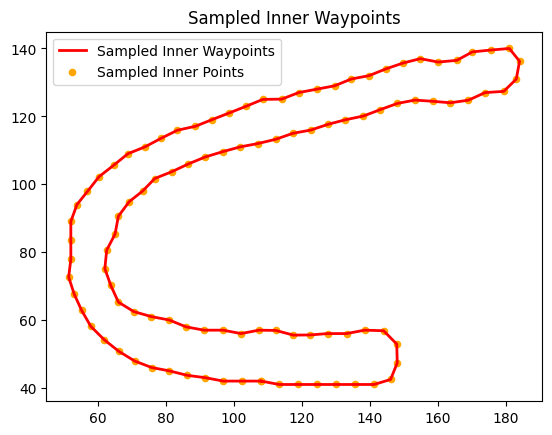

In [35]:
inner_waypoints = sample_waypoints(inner_border, 100)
# Plot sampled waypoints
plt.plot(inner_waypoints[:,0], inner_waypoints[:,1], 'r-', linewidth=2, label='Sampled Inner Waypoints')
# Put actual scatter points to see them
plt.scatter(inner_waypoints[:,0], inner_waypoints[:,1], c='orange', s=20, label='Sampled Inner Points')
plt.title('Sampled Inner Waypoints')
plt.legend()
plt.show()

In [36]:
len(inner_waypoints), len(outer_waypoints)

(100, 100)

In [37]:
# Now find the inner and outer waypoints that are closest to the start line
def find_closest_waypoint(
    start_line_coords: NDArray[np.floating],
    waypoints: NDArray[np.floating]
) -> Tuple[int, float]:
    """
    Find the waypoint from the 'waypoints' array that has the minimum distance
    to any point in the 'start_line_coords' array.

    Calculates the minimum distance from each waypoint to the set of
    start line coordinates and finds the waypoint with the overall smallest
    minimum distance.

    Args:
        start_line_coords: A numpy array of shape (N, 2) containing the
                           coordinates of the points on the start line (N can be any number).
                           Must contain floating-point numbers.
        waypoints: A numpy array of shape (M, 2) containing the coordinates
                   of the waypoints (M can be any number, different from N).
                   Must contain floating-point numbers.

    Returns:
        A tuple containing:
        - The index (an integer) of the closest waypoint in the original waypoints array.
        - The minimum distance (a float) from this waypoint to any point on the start line.

    Raises:
        ValueError: If either input array is empty or does not have the shape (N, 2).
        TypeError: If input arrays do not contain floating-point numbers (based on type hint).
    """
    # Input validation
    # Check dimensions and shape
    if start_line_coords.ndim != 2 or start_line_coords.shape[1] != 2:
        raise ValueError("start_line_coords must be a numpy array of shape (N, 2).")
    if waypoints.ndim != 2 or waypoints.shape[1] != 2:
        raise ValueError("waypoints must be a numpy array of shape (M, 2).")

    # Check if arrays are empty
    if start_line_coords.shape[0] == 0:
        raise ValueError("start_line_coords cannot be empty.")
    if waypoints.shape[0] == 0:
         # Cannot find a closest waypoint if there are no waypoints
        raise ValueError("waypoints cannot be empty.")

    # Ensure arrays have floating-point dtype for linalg.norm
    if not np.issubdtype(start_line_coords.dtype, np.floating):
         start_line_coords = start_line_coords.astype(np.float64)
    if not np.issubdtype(waypoints.dtype, np.floating):
         waypoints = waypoints.astype(np.float64)


    # Calculate the distance from each waypoint to each point on the start line
    # This is done using broadcasting:
    # waypoints[:, np.newaxis, :] reshapes waypoints from (M, 2) to (M, 1, 2)
    # start_line_coords[np.newaxis, :, :] reshapes start_line_coords from (N, 2) to (1, N, 2)
    # The subtraction (M, 1, 2) - (1, N, 2) broadcasts to (M, N, 2), where
    # element [i, j, :] is the vector from waypoint i to start_line_coord j.
    # np.linalg.norm calculates the magnitude of these vectors along the last axis (axis=2).
    # This results in a (M, N) array where element [i, j] is the distance from waypoint i
    # to start_line_coord j.
    distances_matrix: NDArray[np.floating] = np.linalg.norm(
        waypoints[:, np.newaxis, :] - start_line_coords[np.newaxis, :, :],
        axis=2
    )

    # For each waypoint (each row in distances_matrix), find the minimum distance
    # to any point on the start line. This gives an (M,) array of minimum distances
    # for each waypoint.
    min_distances_to_line_per_waypoint: NDArray[np.floating] = np.min(distances_matrix, axis=1)

    # Find the index of the waypoint with the overall minimum distance
    closest_waypoint_index: int = np.argmin(min_distances_to_line_per_waypoint)

    return closest_waypoint_index

Closest outer waypoint to start line is at index 95 with distance 95.00


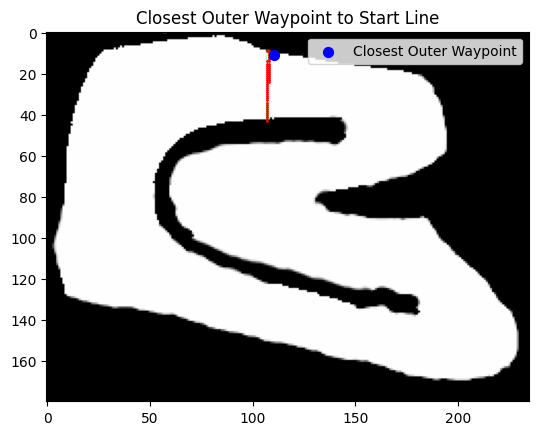

In [38]:
closest_outer_start_line_index = find_closest_waypoint(start_line_coords, outer_waypoints)
print(f"Closest outer waypoint to start line is at index {closest_outer_start_line_index} with distance {closest_outer_start_line_index:.2f}")
# Plot the closest waypoint
plt.imshow(start_line_img)
plt.scatter(start_line_coords[:, 0], start_line_coords[:, 1], c='red', s=1)  # Red dots for start line  
plt.scatter(outer_waypoints[closest_outer_start_line_index, 0], outer_waypoints[closest_outer_start_line_index, 1], c='blue', s=50, label='Closest Outer Waypoint')
plt.title('Closest Outer Waypoint to Start Line')
plt.legend()

Closest outer waypoint to start line is at index 0 with distance 0.00


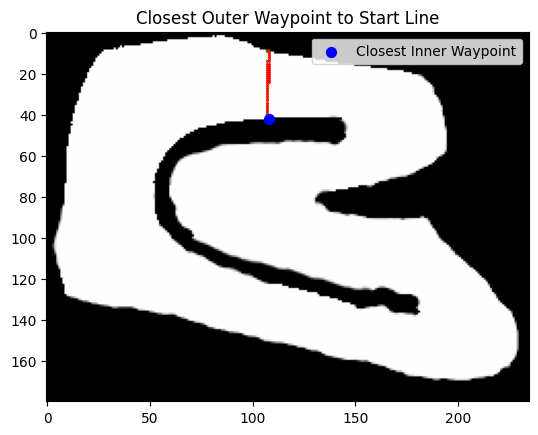

In [39]:
closest_inner_start_line_index = find_closest_waypoint(start_line_coords, inner_waypoints)
print(f"Closest outer waypoint to start line is at index {closest_inner_start_line_index} with distance {closest_inner_start_line_index:.2f}")
# Plot the closest waypoint
plt.imshow(start_line_img)
plt.scatter(start_line_coords[:, 0], start_line_coords[:, 1], c='red', s=1)  # Red dots for start line  
plt.scatter(inner_waypoints[closest_inner_start_line_index, 0], inner_waypoints[closest_inner_start_line_index, 1], c='blue', s=50, label='Closest Inner Waypoint')
plt.title('Closest Outer Waypoint to Start Line')
plt.legend()

In [40]:
def reorder_waypoints_cyclic(
    waypoints: NDArray[np.floating],
    start_index: int,
    reverse_direction: bool = False
) -> NDArray[np.floating]:
    """
    Cyclically reorders a numpy array of waypoints so that the point at
    start_index becomes the first point (index 0). Optionally reverses
    the order of the points after the cyclic shift.

    Args:
        waypoints: A numpy array of waypoints, expected shape (N, 2)
                   with floating-point coordinates.
        start_index: The index (an integer) of the waypoint in the input
                     array that should become the new starting point (index 0).
        reverse_direction: If True, the order of the points will be reversed
                           after the cyclic shift is applied. Defaults to False.

    Returns:
        A new numpy array with the waypoints cyclically reordered and
        optionally reversed. Returns an empty array if the input is empty.

    Raises:
        TypeError: If start_index is not an integer or reverse_direction is not boolean.
        ValueError: If the waypoints array does not have the expected shape
                    or if start_index is out of the valid range for the array.
    """
    # Input validation
    if not isinstance(start_index, int):
        raise TypeError("start_index must be an integer.")
    if not isinstance(reverse_direction, bool):
         raise TypeError("reverse_direction must be a boolean (True or False).")


    if waypoints.ndim != 2 or waypoints.shape[1] != 2:
         raise ValueError("waypoints must be a numpy array of shape (N, 2).")

    num_waypoints = waypoints.shape[0]

    if num_waypoints == 0:
        # print("Warning: Attempted to reorder or reverse an empty waypoints array.")
        return waypoints # Return empty array if input is empty

    if not (0 <= start_index < num_waypoints):
        raise ValueError(
            f"start_index {start_index} is out of bounds for waypoints array "
            f"with {num_waypoints} points. Valid range is 0 to {num_waypoints - 1}."
        )

    # 1. Perform the cyclic shift using np.roll
    # We shift by -start_index along axis 0 (the rows/points dimension).
    # Shifting by -k moves the element at index k to index 0.
    reordered_waypoints: NDArray[np.floating] = np.roll(waypoints, shift=-start_index, axis=0)

    # 2. Optionally reverse the direction
    if reverse_direction:
        # Reverse the array along the first axis (the rows/points)
        reordered_waypoints = reordered_waypoints[::-1]

        # Note: After reversing, the point that was originally at start_index
        # will still be at index 0. The *sequence* of points that follows
        # will be reversed compared to the non-reversed version.


    return reordered_waypoints

In [41]:
closest_inner_start_line_index

np.int64(0)

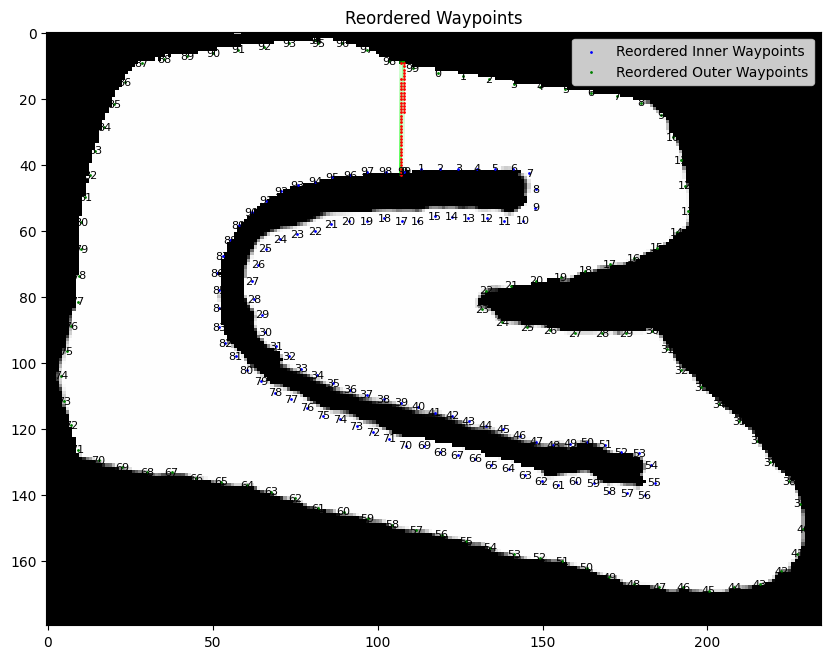

In [42]:
inner_waypoints = reorder_waypoints_cyclic(inner_waypoints, int(closest_inner_start_line_index))
outer_waypoints = reorder_waypoints_cyclic(outer_waypoints, int(closest_outer_start_line_index), reverse_direction=True)
# Plot the reordered waypoints
plt.figure(figsize=(10, 8))
plt.imshow(start_line_img)
plt.scatter(start_line_coords[:, 0], start_line_coords[:, 1], c='red', s=1)  # Red dots for start line
plt.scatter(inner_waypoints[:, 0], inner_waypoints[:, 1], c='blue', s=1, label='Reordered Inner Waypoints')
# Label the index of each waypoint
for i, (x, y) in enumerate(inner_waypoints):
    plt.text(x, y, str(i), fontsize=8, color='black', ha='center', va='center')
plt.scatter(outer_waypoints[:, 0], outer_waypoints[:, 1], c='green', s=1, label='Reordered Outer Waypoints')
for i, (x, y) in enumerate(outer_waypoints):
    plt.text(x, y, str(i), fontsize=8, color='black', ha='center', va='center')
plt.title('Reordered Waypoints')
plt.legend()

In [43]:
def get_centerline(outer_waypoints: np.ndarray, inner_waypoints: np.ndarray) -> np.ndarray:
    """
    Compute the centerline between two sets of waypoints.
    """
    # Ensure both arrays are of the same length
    if len(outer_waypoints) != len(inner_waypoints):
        raise ValueError("Outer and inner waypoints must have the same length.")

    # Compute midpoints
    midpoints = (outer_waypoints + inner_waypoints) / 2
    return midpoints

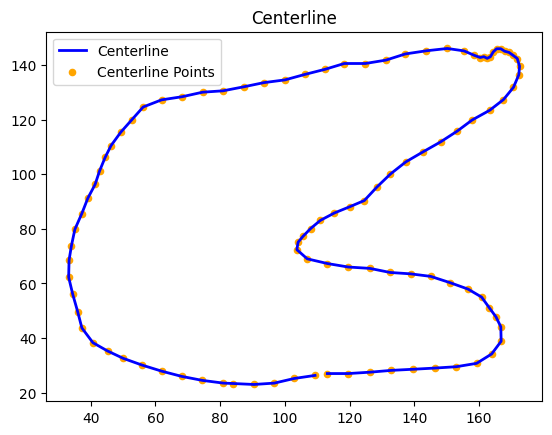

In [44]:
center_line = get_centerline(outer_waypoints, inner_waypoints)
# Plot centerline
plt.plot(center_line[:,0], center_line[:,1], 'b-', linewidth=2, label='Centerline')
# Put actual scatter points to see them
plt.scatter(center_line[:,0], center_line[:,1], c='orange', s=20, label='Centerline Points')
plt.title('Centerline')
plt.legend()
plt.show()


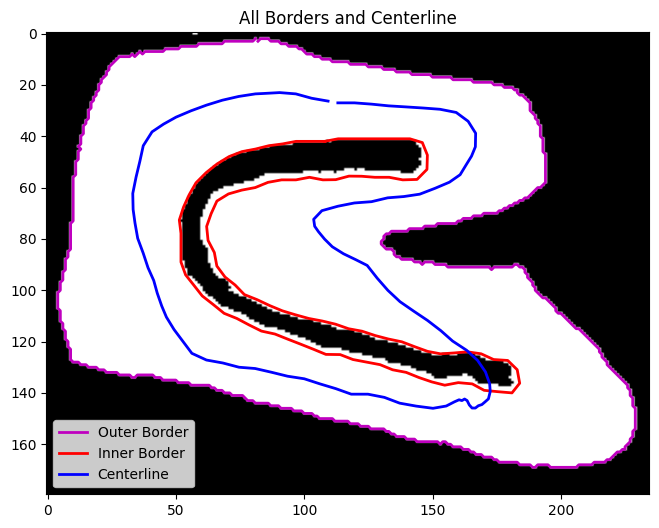

In [45]:
# show all lines together
plt.figure(figsize=(8, 6))
plt.imshow(img, cmap='gray')  # Show the binary image as background
# Plot outer border
outer_x = [p[0] for p in outer_border]
outer_y = [p[1] for p in outer_border]
plt.plot(outer_x, outer_y, 'm-', linewidth=2, label='Outer Border')
# Plot inner border
inner_x = [p[0] for p in inner_waypoints]   
inner_y = [p[1] for p in inner_waypoints]
plt.plot(inner_x, inner_y, 'r-', linewidth=2, label='Inner Border')
# Plot centerline
center_x = [p[0] for p in center_line]
center_y = [p[1] for p in center_line]
plt.plot(center_x, center_y, 'b-', linewidth=2, label='Centerline')
plt.title('All Borders and Centerline')
plt.legend()
plt.show()

# Try with Skeleton


In [ ]:
import cv2
import numpy as np

cv2.distanceTransform(binary, cv2.DIST_L2, 5)

def get_center_line_via_skeleton() -> np.ndarray:
    import cv2
    dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    max_dist = np.max(dist_transform[binary > 0])
    thresh_value = max_dist * 0.3  # Try 0.3 or 0.2 to widen the skeleton initially
    _, skeleton = cv2.threshold(dist_transform, thresh_value, 255, cv2.THRESH_BINARY)
    skeleton = skeleton.astype(np.uint8)

    try:
        import cv2
        skeleton = cv2.ximgproc.thinning(skeleton)  # Preferred if available
        print("Using OpenCV thinning.")
    except ImportError:
        kernel = np.ones((3, 3), np.uint8)
        skeleton = cv2.erode(skeleton, kernel, iterations=1)
    return skeleton

Using OpenCV thinning.


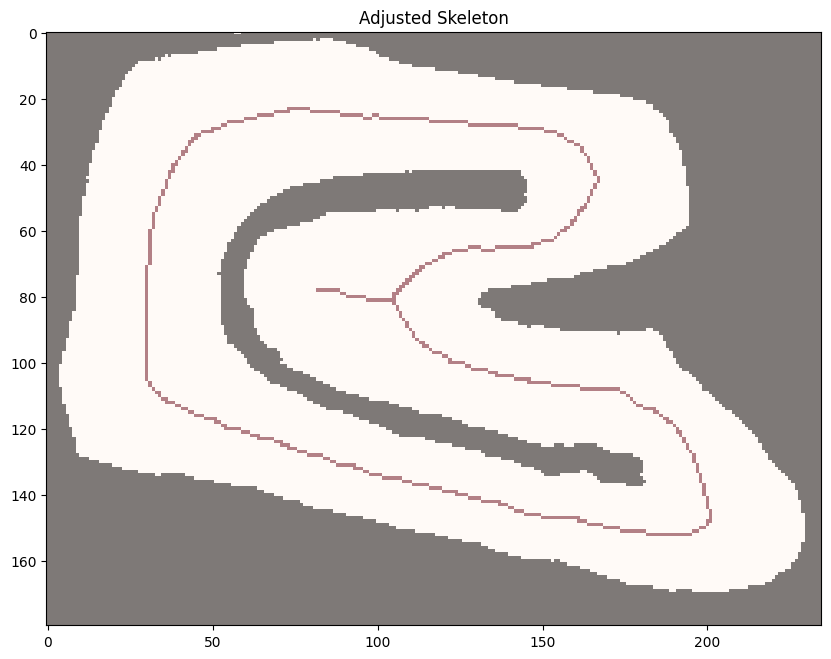

Skeleton pixels: 624


In [63]:
center_line = get_center_line_via_skeleton()

# Check result
plt.figure(figsize=(10, 8))
plt.imshow(binary, cmap='gray')
plt.imshow(center_line, cmap='Reds', alpha=0.5)
plt.title('Adjusted Skeleton')
plt.show()
print(f"Skeleton pixels: {cv2.countNonZero(center_line)}")

In [64]:
def prune_skeleton_branches(skeleton_binary_image: NDArray[np.uint8], min_branch_length: int) -> NDArray[np.uint8]:
    """
    Prunes short branches from a binary skeleton image using iterative endpoint removal.

    Args:
        skeleton_binary_image: A binary image (255 for skeleton pixels, 0 for background).
                               Expected dtype is np.uint8. Must be a 2D array.
        min_branch_length: The minimum length of branches (in pixels, approximately)
                           to keep. Shorter branches will be pruned by removing
                           endpoints iteratively this many times.

    Returns:
        A new binary image (np.uint8) with short branches removed.
        Returns an empty array if the input is not a valid image.
    """
    # Validate input image
    if not isinstance(skeleton_binary_image, np.ndarray) or skeleton_binary_image.ndim != 2:
         print("Error: Input must be a 2D numpy array (image).")
         return np.empty((0, 0), dtype=np.uint8) # Return empty on invalid input

    if skeleton_binary_image.dtype != np.uint8:
        # print("Warning: Input image dtype is not uint8. Attempting conversion.")
        skeleton_binary_image = skeleton_binary_image.astype(np.uint8)

    # Ensure the image is strictly binary (0 or 255) based on positive values
    # This handles cases where skeleton might be > 0 but not exactly 255
    skeleton_binary_image = (skeleton_binary_image > 0).astype(np.uint8) * 255


    pruned_skeleton = skeleton_binary_image.copy()
    # height, width = pruned_skeleton.shape # Not strictly needed for the logic


    # Define a kernel for 8-connectivity neighborhood check
    # Used for calculating the sum of neighbors around a pixel
    kernel = np.ones((3, 3), dtype=np.uint8)

    # Iterate multiple times to remove branches up to min_branch_length
    # Each iteration removes one layer of endpoints
    for i in range(min_branch_length):
        # Find pixels that are part of the skeleton (value > 0, which is 255)
        skeleton_pixels_y, skeleton_pixels_x = np.where(pruned_skeleton > 0)
        num_skeleton_pixels = len(skeleton_pixels_y)

        if num_skeleton_pixels == 0:
            # print(f"Pruning stopped at iteration {i}: Skeleton became empty.")
            break # Stop if the skeleton becomes empty

        # Calculate the sum of the 8 neighbors for each pixel in the binary skeleton
        # We convolve with the kernel. borderType=cv2.BORDER_CONSTANT ensures
        # pixels outside the image are treated as 0.
        # The result 'neighbor_sum' for a pixel (r, c) is the sum of the 3x3
        # neighborhood in 'binary_skeleton' centered at (r, c).
        binary_skeleton_float = (pruned_skeleton > 0).astype(np.float64) # Use float for convolution
        neighbor_sum = cv2.filter2D(binary_skeleton_float, -1, kernel, borderType=cv2.BORDER_CONSTANT)

        # Subtract the center pixel's value (which is 1 if it's a skeleton pixel)
        # from the sum to get the sum of its actual neighbors.
        neighbor_count = neighbor_sum - binary_skeleton_float

        # Find endpoints: These are skeleton pixels (value > 0) with exactly 1 neighbor.
        # In the 'neighbor_count' image, these are pixels that were originally skeleton (>0)
        # and where neighbor_count == 1.0.
        # Use the original 'pruned_skeleton' to identify where skeleton pixels are.
        endpoints_mask = (pruned_skeleton > 0) & (neighbor_count == 1.0)

        # Get the coordinates of the endpoints
        endpoints_y, endpoints_x = np.where(endpoints_mask)

        if len(endpoints_y) == 0:
            # print(f"Pruning stopped at iteration {i}: No more endpoints found.")
            break # No more endpoints to remove, pruning is complete for this iteration count.

        # Set the identified endpoints to 0 (background) in the pruned skeleton image
        pruned_skeleton[endpoints_y, endpoints_x] = 0

        # Optional: You could add a check here to see if any pixels were removed in this iteration.
        # If no pixels were removed, the skeleton has stabilized, and you can break early.


    # Return the pruned binary image
    return pruned_skeleton

In [82]:
pruning_factor = 30
pruned_centerline = prune_skeleton_branches(center_line, pruning_factor)


In [99]:
def extract_center_line_points(skeleton: np.ndarray) -> np.ndarray:
    """
    Extracts the coordinates of the center line points from a binary skeleton image using contours.

    Args:
        skeleton: A binary image (np.uint8) representing the skeleton (0 for background, non-zero for skeleton).

    Returns:
        A numpy array of shape (N, 2) containing the (x, y) coordinates of the center line points in sequential order.
    """
    # Ensure the skeleton is binary (0 or 255)
    _, skeleton = cv2.threshold(skeleton, 1, 255, cv2.THRESH_BINARY)

    # Find contours
    contours, _ = cv2.findContours(skeleton, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    # Check if any contours were found
    if not contours:
        print("Error: No contours found. Ensure the skeleton contains non-zero pixels.")
        return np.array([], dtype=np.float64)

    # Select the first contour (assuming a single skeleton line)
    contour = contours[0]

    # Extract points from the contour
    # Contour points are in the format [[[x, y]], [[x, y]], ...]
    points = contour.reshape(-1, 2).astype(np.float64)

    print(f"Extracted {len(points)} points from contour")
    return points

In [100]:
pruned_centerline_points = extract_center_line_points(pruned_centerline)
pruned_centerline_points

Extracted 560 points from contour


array([[73., 23.],
       [72., 24.],
       [71., 24.],
       ...,
       [76., 23.],
       [75., 23.],
       [74., 23.]], shape=(560, 2))

Text(0.5, 1.0, 'Pruned Centerline Points')

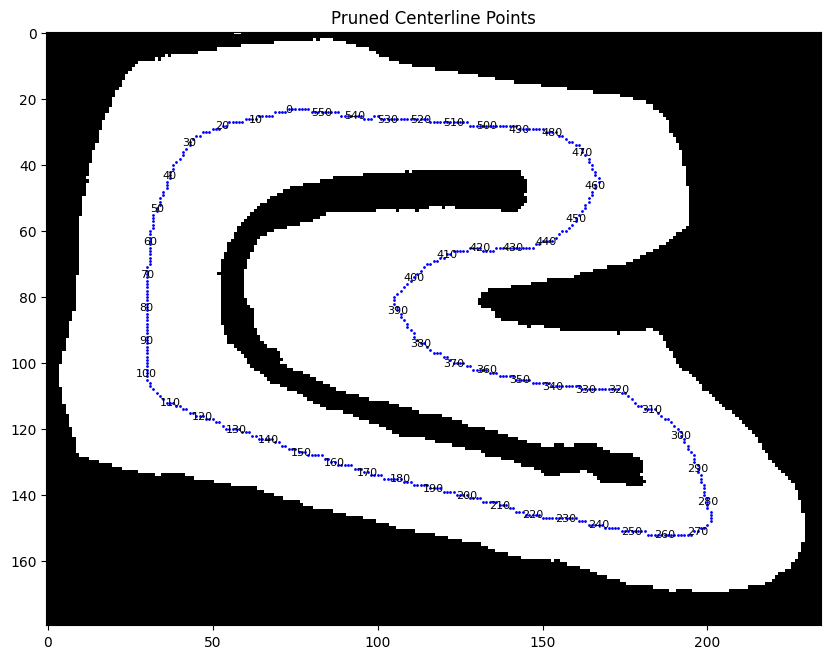

In [102]:
# Show the pruned centerline points
plt.figure(figsize=(10, 8))
plt.imshow(binary, cmap='gray')
plt.scatter(pruned_centerline_points[:, 0], pruned_centerline_points[:, 1], c='blue', s=1)  # Blue dots for pruned centerline
for i, (x, y) in enumerate(pruned_centerline_points):
    if i % 10 == 0:
        plt.text(x, y, str(i), fontsize=8, color='black', ha='center', va='center')
plt.title('Pruned Centerline Points')


In [85]:
center_line_coords = sample_waypoints(pruned_centerline_points, 100)

Text(0.5, 1.0, 'Pruned Centerline Points')

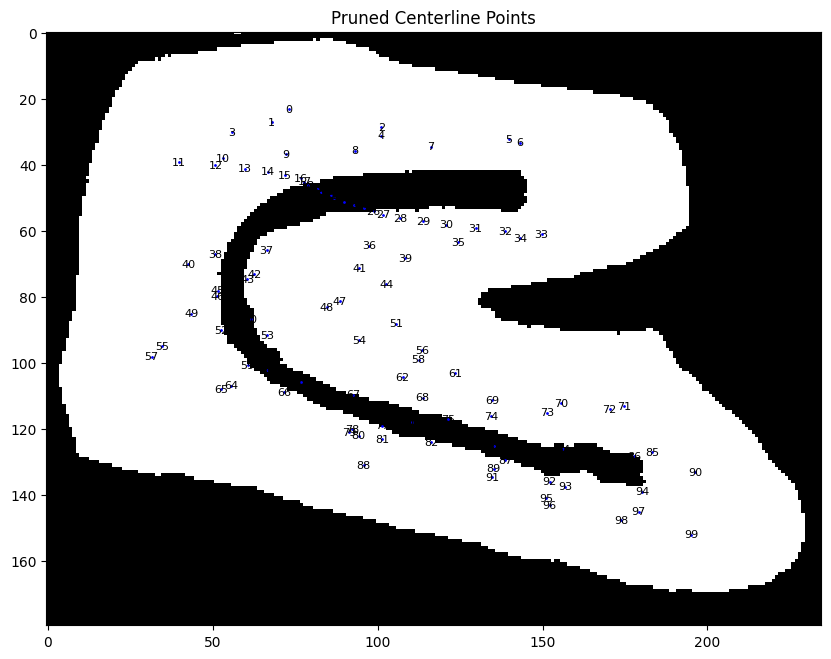

In [93]:
# Check result
plt.figure(figsize=(10, 8))
plt.imshow(binary, cmap='gray')
plt.scatter(center_line_coords[:, 0], center_line_coords[:, 1], c='blue', s=1)  # Blue dots for pruned centerline
# Show the pruned centerline points index
for i, (x, y) in enumerate(center_line_coords):
    # if i % 10 == 0:  # Show every 10th point
        plt.text(x, y, str(i), fontsize=8, color='black', ha='center', va='center')
plt.title('Pruned Centerline Points')

In [ ]:
import numpy as np

from pathlib import Path
from skimage.morphology import medial_axis
import csv

def extract_track(
    image_path: str,
    resolution: float,
    invert: bool = False,
    output_dir: str = "../tmp"
) -> None:
    """
    Process a track image to extract outer boundary, inner boundary, and centerline.

    Args:
        image_path: Path to the input image (grayscale or color).
        resolution: Scaling factor to convert pixel coords to real-world units.
        invert: If True, invert binary image (useful when track is light on dark).
        output_dir: Directory to save output CSVs.
    """
    # Prepare paths
    img_p = Path(image_path)
    out_p = Path(output_dir)
    out_p.mkdir(exist_ok=True, parents=True)

    # Load image in grayscale
    img = cv2.imread(str(img_p), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot load image: {img_p}")

    # Threshold to binary
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    if invert:
        binary = 255 - binary

    # Find external contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        raise RuntimeError("No contours found in image.")

    # Outer boundary: largest contour
    outer = max(contours, key=cv2.contourArea).reshape(-1, 2)

    # Inner boundary: erode and find smallest contour
    kernel = np.ones((3, 3), np.uint8)
    eroded = cv2.erode(binary, kernel, iterations=3)
    contours_i, _ = cv2.findContours(eroded, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    inner = None
    if contours_i:
        candidate = min(contours_i, key=cv2.contourArea).reshape(-1, 2)
        if cv2.contourArea(candidate) >= 50:
            inner = candidate
    if inner is None:
        raise RuntimeError("Inner contour not found or too small.")

    # Centerline via Medial Axis Transform
    binary_bool = binary > 0
    skeleton_bool, _ = medial_axis(binary_bool, return_distance=True)
    skeleton_pts = np.column_stack(np.where(skeleton_bool))[:, ::-1]  # x,y order

    # Scale coordinates by resolution
    outer_scaled = outer * resolution
    inner_scaled = inner * resolution
    center_scaled = skeleton_pts * resolution

    # Define save helper
    def save_csv(points: np.ndarray, fname: str):
        file = out_p / fname
        with open(file, 'w', newline='') as f:
            w = csv.writer(f)
            w.writerow(['x', 'y'])
            for x, y in points:
                w.writerow([x, y])

    # Save files
    save_csv(outer_scaled, 'outer_boundary.csv')
    save_csv(inner_scaled, 'inner_boundary.csv')
    save_csv(center_scaled, 'centerline.csv')

    print(f"Saved outer boundary: {out_p/'outer_boundary.csv'}")
    print(f"Saved inner boundary: {out_p/'inner_boundary.csv'}")
    print(f"Saved centerline: {out_p/'centerline.csv'}")


# Example usage:
# extract_track('path/to/map.pgm', resolution=0.5, invert=True, output_dir='output')
